Read the VCF and extract info to be turned into features

In [64]:
import gzip, math
from collections import Counter
from pathlib import Path
import numpy as np, pandas as pd

TP_VCF_WGS = "tp-comp_wgs.vcf"
FP_VCF_WGS = "fp_wgs.vcf"

TP_VCF_22 = "tp-comp_22.vcf"
FP_VCF_22 = "fp_22.vcf"


# Optional per-variant summary annotations. These TSVs are produced outside the VCF
# and are currently chr22-only in this folder. They are loaded into `calls` below;
# model-safe columns are added as features, while truth/window columns are kept for
# diagnostics to avoid training directly on label-adjacent information.
SUMMARY_TP_TSV = Path.cwd() / "tp" / "all_variants.summary.tsv"
SUMMARY_FP_TSV = Path.cwd() / "fp" / "all_variants.summary.tsv"

SUMMARY_ID_COL = "VAR"  # matches VCF ID for Sniffles2 calls
SUMMARY_EXCLUDE_FEATURES = {
    "SV_DIR", "VAR", "CHROM", "POS", "END", "SVTYPE", "SVLEN",
    "MATE_CHROM", "MATE_POS", "REGION",
    # These encode whether MIMS truth calls are nearby, so keep them for audit plots
    # rather than model training unless you explicitly want a truth-assisted analysis.
    "MIMS_TRUTH_IN_WINDOW", "MIMS_TRUTH_SAME_TYPE_IN_WINDOW", "MIMS_REGIONS_IN_WINDOW",
}
SUMMARY_DIAGNOSTIC_COLS = [
    "MIMS_TRUTH_IN_WINDOW", "MIMS_TRUTH_SAME_TYPE_IN_WINDOW", "MIMS_REGIONS_IN_WINDOW",
]

def read_variant_summary(path, y=None):
    """Read one all_variants.summary_*.tsv file and prefix feature columns."""
    s = pd.read_csv(path, sep="\t")
    if y is not None:
        s["summary_y"] = y
    keep = [c for c in s.columns if c not in {"CHROM", "POS", "END", "SVTYPE", "SVLEN"}]
    s = s[keep].copy()
    rename = {c: "SUM_" + c.lower() for c in s.columns if c not in {SUMMARY_ID_COL, "summary_y"}}
    return s.rename(columns=rename)


def load_variant_summaries(tp_path=SUMMARY_TP_TSV, fp_path=SUMMARY_FP_TSV):
    """Load TP/FP summary TSVs if present; return None if they are unavailable."""
    tp_path, fp_path = resolve_summary_path(tp_path), resolve_summary_path(fp_path)
    missing = [str(p) for p in [tp_path, fp_path] if not p.exists()]
    if missing:
        print(f"summary TSV(s) not found, skipping summary features: {missing}")
        return None
    summary = pd.concat([
        read_variant_summary(tp_path, y=1),
        read_variant_summary(fp_path, y=0),
    ], ignore_index=True)
    if summary[SUMMARY_ID_COL].duplicated().any():
        n = int(summary[SUMMARY_ID_COL].duplicated().sum())
        print(f"!! {n} duplicated summary IDs; keeping first occurrence")
        summary = summary.drop_duplicates(SUMMARY_ID_COL, keep="first")
    print(f"loaded {len(summary)} summary rows from all_variants summary TSVs")
    return summary


def attach_variant_summary(df, summary=None):
    """Left-join all summary columns onto a VCF-derived call table by ID."""
    if summary is None:
        return df.copy()
    out = df.merge(summary, left_on="ID", right_on=SUMMARY_ID_COL, how="left", validate="m:1")
    matched = int(out[SUMMARY_ID_COL].notna().sum())
    print(f"summary matched {matched}/{len(out)} calls ({matched / max(len(out), 1):.1%})")
    return out


def summary_feature_columns(df, include_truth=False):
    """Summary columns eligible for the model feature matrix."""
    blocked = {"SUM_" + c.lower() for c in SUMMARY_EXCLUDE_FEATURES}
    if include_truth:
        blocked -= {"SUM_" + c.lower() for c in SUMMARY_DIAGNOSTIC_COLS}
    return [c for c in df.columns if c.startswith("SUM_") and c not in blocked]

# Adding these as features would just give it the answer, because it's what truvari calculates
LEAK = {"TruScore", "PctSeqSimilarity", "PctSizeSimilarity", "PctRecOverlap",
        "StartDistance", "EndDistance", "SizeDiff", "GTMatch", "MatchId",
        "Multi", "NumCollapsed", "RNAMES"}

def read_vcf(path):
    """VCF -> DataFrame. INFO keys become features, sample fields become FMT_* columns."""
    op = gzip.open if str(path).endswith(".gz") else open
    rows = []
    with op(path, "rt") as fh:
        for line in fh:
            if line.startswith("#"):
                continue
            f = line.rstrip("\n").split("\t")
            r = {"CHROM": f[0], "POS": int(f[1]), "ID": f[2], "REF": f[3], "ALT": f[4], "QUAL": f[5], "FILTER": f[6]}
            for kv in f[7].split(";"):
                k, _, v = kv.partition("=") # 2 empty strings if the partitions not found _ is = in this case
                if k not in LEAK:
                    r[k] = v if v else True #set to true for like MOSAIC or PRECISE
            for k, v in zip(f[8].split(":"), f[9].split(":")): #GT:GQ:DR:DV:PS	0/0:60:233:3:.    #FORMAT	HapMap6_ONT_ALL5
                r["FMT_" + k] = v
            rows.append(r)
    return pd.DataFrame(rows)

Defining the features

In [65]:
def col(df, name):
    return df[name] if name in df.columns else pd.Series(np.nan, index=df.index)

def numcol(df, name):
    return pd.to_numeric(col(df, name), errors="coerce")

def gc_frac(s):
    n = sum(c in "ACGT" for c in s)
    return (s.count("G") + s.count("C")) / n if n else np.nan

def di_entropy(s): # this could be used if we don't have a trf, but otherwise we can just pass it in
    """Dinucleotide entropy of the inserted/deleted sequence. Low = repetitive (TR-like)."""
    if len(s) < 3:
        return np.nan
    c = Counter(s[i:i + 2] for i in range(len(s) - 1))
    tot = sum(c.values())
    return -sum((v / tot) * math.log2(v / tot) for v in c.values())


# =============================================================================
#  Neighbourhood / co-location features
# =============================================================================
NB_WINDOWS = (100, 500, 1000)
NB_MAXDIST = 1_000_000          # cap: beyond this, "how far" stops mattering
NB_PAD     = 25                 # give point-like calls (INS) a footprint

def sv_end(df):
    """Right edge of each call. INS occupies a point; DEL/DUP/INV span SVLEN."""
    pos   = pd.to_numeric(df["POS"], errors="coerce")
    end   = pd.to_numeric(col(df, "END"), errors="coerce")
    svlen = pd.to_numeric(col(df, "SVLEN"), errors="coerce").abs()
    svt   = col(df, "SVTYPE").astype(str)
    fb    = np.where(svt.to_numpy() == "INS", pos.to_numpy(),
                     pos.to_numpy() + svlen.fillna(0).to_numpy())
    e = end.to_numpy(dtype=float)
    ok = np.isfinite(e) & (e >= pos.to_numpy())
    return pd.Series(np.where(ok, e, fb), index=df.index).astype(float)


def neighbor_features(query, ref, windows=NB_WINDOWS, pad=NB_PAD):
    """How crowded is each call in `query`, measured against every OTHER call in `ref`?

    ref MUST be the complete callset -- TP and FP concatenated, all contigs.

    Why: if you computed density inside tp.vcf alone, a true positive would look
    crowded only because the calls around it are also in tp.vcf. "Number of
    neighbours" would then be a partial restatement of the label. Using the union
    removes that: the union is exactly what the caller emitted, which is what you
    have at scoring time too. Same rule when applying -- pass the same full callset
    as `ref`, never the single file being annotated.

    Self-matches are dropped by VCF ID, so a call present in both frames is not
    counted as its own neighbour.

    Columns
      nb_n_1kb / nb_n_10kb / nb_n_100kb  other calls with POS inside that window
      nb_n_same_1kb                      same SVTYPE within 1 kb
      nb_n_overlap                       other calls whose padded interval overlaps
      nb_log_dist                        log10(bp to nearest other call + 1)
      nb_log_dist_same                   same, restricted to the same SVTYPE
      nb_best_jaccard                    best padded-interval Jaccard with any other
                                         call -- ~1.0 means a near-duplicate record
      nb_best_size_ratio                 best min/max SVLEN ratio among same-type
                                         calls within 1 kb (same event, two sizes)

    Approximation: candidates are drawn from a +/-max(window, own span) band, so a
    very long neighbour starting far upstream can be missed by nb_n_overlap. Fine
    for SVs under ~100 kb.
    """
    qpos = pd.to_numeric(query["POS"], errors="coerce").to_numpy(float)
    qend = sv_end(query).to_numpy(float)
    qchr = query["CHROM"].astype(str).to_numpy()
    qsvt = col(query, "SVTYPE").astype(str).to_numpy()
    qid  = query["ID"].astype(str).to_numpy()
    qlen = pd.to_numeric(col(query, "SVLEN"), errors="coerce").abs().to_numpy(float)

    rpos = pd.to_numeric(ref["POS"], errors="coerce").to_numpy(float)
    rend = sv_end(ref).to_numpy(float)
    rchr = ref["CHROM"].astype(str).to_numpy()
    rsvt = col(ref, "SVTYPE").astype(str).to_numpy()
    rid  = ref["ID"].astype(str).to_numpy()
    rlen = pd.to_numeric(col(ref, "SVLEN"), errors="coerce").abs().to_numpy(float)

    def _sorted_index(keys):
        d = {}
        for k in np.unique(keys):
            idx = np.flatnonzero(keys == k)
            o = np.argsort(rpos[idx], kind="stable")
            d[k] = (rpos[idx][o], idx[o])
        return d

    by_chr = _sorted_index(rchr)
    by_chr_type = _sorted_index(
        np.array([f"{a}\t{b}" for a, b in zip(rchr, rsvt)], dtype=object))

    def _nearest(ent, p, self_id, span=6):
        """Exact distance to the closest other call: in a sorted 1-D array the
        nearest point is adjacent, so only a few entries either side are checked
        (the extra span covers duplicate positions and the self-match)."""
        if ent is None:
            return float(NB_MAXDIST)
        ps_, idx_ = ent
        k = np.searchsorted(ps_, p)
        best = float(NB_MAXDIST)
        for j in range(max(0, k - span), min(len(ps_), k + span)):
            if rid[idx_[j]] == self_id:
                continue
            dd = abs(ps_[j] - p)
            if dd < best:
                best = float(dd)
        return best

    n    = len(query)
    maxw = max(windows)
    cnt  = {w: np.zeros(n, np.int32) for w in windows}
    n_same1k = np.zeros(n, np.int32)
    n_ovl    = np.zeros(n, np.int32)
    d_any    = np.full(n, float(NB_MAXDIST))
    d_same   = np.full(n, float(NB_MAXDIST))
    best_jac = np.zeros(n, float)
    best_sr  = np.zeros(n, float)

    for i in range(n):
        ent = by_chr.get(qchr[i])
        if ent is None:
            continue

        # exact nearest-neighbour distances (not limited by the window below)
        d_any[i]  = _nearest(ent, qpos[i], qid[i])
        d_same[i] = _nearest(by_chr_type.get(qchr[i] + "\t" + qsvt[i]), qpos[i], qid[i])

        ps, idx = ent
        reach = max(maxw, (qend[i] - qpos[i]) + 1000.0)
        lo = np.searchsorted(ps, qpos[i] - reach, "left")
        hi = np.searchsorted(ps, qpos[i] + reach, "right")
        cand = idx[lo:hi]
        cand = cand[rid[cand] != qid[i]]
        if cand.size == 0:
            continue

        d = np.abs(rpos[cand] - qpos[i])
        for w in windows:
            cnt[w][i] = int((d <= w).sum())

        same = rsvt[cand] == qsvt[i]
        if same.any():
            near = same & (d <= 1000)
            n_same1k[i] = int(near.sum())
            if near.any() and np.isfinite(qlen[i]) and qlen[i] > 0:
                b = rlen[cand][near]
                with np.errstate(invalid="ignore", divide="ignore"):
                    r = np.minimum(qlen[i], b) / np.maximum(qlen[i], b)
                r = r[np.isfinite(r)]
                if r.size:
                    best_sr[i] = float(r.max())

        s1, e1 = qpos[i] - pad, max(qend[i], qpos[i]) + pad
        s2 = rpos[cand] - pad
        e2 = np.maximum(rend[cand], rpos[cand]) + pad
        inter = np.minimum(e1, e2) - np.maximum(s1, s2)
        ovl = inter > 0
        n_ovl[i] = int(ovl.sum())
        if ovl.any():
            union = np.maximum(e1, e2) - np.minimum(s1, s2)
            with np.errstate(invalid="ignore", divide="ignore"):
                j = inter[ovl] / union[ovl]
            j = j[np.isfinite(j)]
            if j.size:
                best_jac[i] = float(j.max())

    F = pd.DataFrame(index=query.index)
    for w in windows:
        F[f"nb_n_{w // 1000}kb"] = cnt[w]
    # F["nb_n_same_1kb"]      = n_same1k
    # F["nb_n_overlap"]       = n_ovl
    # F["nb_log_dist"]        = np.log10(d_any + 1)
    # F["nb_log_dist_same"]   = np.log10(d_same + 1)
    # F["nb_best_jaccard"]    = best_jac
    # F["nb_best_size_ratio"] = best_sr
    return F


def featurize(df, nb_ref=None):
    X = pd.DataFrame(index=df.index)

    # read support / call quality
    X["qual"]         = numcol(df, "QUAL")
    # X["support"]      = numcol(df, "SUPPORT")
    X["support_sa"]   = numcol(df, "SUPPORT_SA").fillna(0)
    X["support_long"] = numcol(df, "SUPPORT_LONG").fillna(0)
    X["vaf"]          = numcol(df, "VAF")
    X["nm"]           = numcol(df, "NM")
    X["stdev_pos"]    = numcol(df, "STDEV_POS")
    X["stdev_len"]    = numcol(df, "STDEV_LEN")
    

    # size and type
    svlen = numcol(df, "SVLEN")
    X["svlen"]     = svlen
    X["stdev_pos_norm"]    = numcol(df, "STDEV_POS") / svlen
    X["stdev_len_norm"]    = numcol(df, "STDEV_LEN") / svlen
    for t in ["INS", "DEL", "DUP"]: #,"INV", "BND"]: #1 hot the sv type. BND and INV don't do anything here, but would be usefull later
        X["is_" + t] = (col(df, "SVTYPE") == t).astype(int)

    # flags
    # X["precise"]     = col(df, "PRECISE").notna().astype(int)
    # X["mosaic"]      = col(df, "MOSAIC").notna().astype(int)
    X["strand_both"] = (col(df, "STRAND") == "+-").astype(int)

    # coverage profile: up, start, center, end, down
    cov = (col(df, "COVERAGE").astype(str).str.split(",", expand=True) #the coverage has 5 different values
            .reindex(columns=range(5)).apply(pd.to_numeric, errors="coerce"))
    cov.columns = ["cov_up", "cov_start", "cov_center", "cov_end", "cov_down"]
    # X = X.join(cov)
    X["cov_ratio"] = cov["cov_center"] / cov[["cov_up", "cov_down"]].mean(axis=1)

    # genotype fields
    dr, dv = numcol(df, "FMT_DR"), numcol(df, "FMT_DV")
    # X["dr"], X["dv"]   = dr, dv
    X["depth"]         = dr + dv
    #X["af_reads"]      = dv / (dr + dv)
    X["gq"]            = numcol(df, "FMT_GQ")

    # sequence composition of the inserted (ALT) or deleted (REF) allele
    seq = pd.Series(np.where(col(df, "SVTYPE") == "INS", df["ALT"], df["REF"]),
                    index=df.index).astype(str).str.upper()
    seq = seq.where(~seq.str.startswith("<"), "")     # symbolic ALTs (<DUP>, <INV>)
    X["gc"]          = seq.map(gc_frac)
    # X["seq_entropy"] = seq.map(di_entropy) #if we cant get the entropy file could be useful

    # ---- neighbourhood, measured against the full callset --------------------
    if nb_ref is not None:
        X = X.join(neighbor_features(df, nb_ref))

    # all_variants.summary_* annotations joined by ID. These are intentionally
    # optional: rows/chromosomes without summary annotations get NaN and the model
    # will receive the existing missing-value sentinel downstream.
    for c in summary_feature_columns(df, include_truth=False):
        s = col(df, c)
        num = pd.to_numeric(s, errors="coerce")
        if num.notna().any():
            X[c] = num
        else:
            X[c] = s.notna().astype(int)

    # TO ADD
    """1. TRF file
    2. Blast of insert sequence info
    3. Close to start of read"""
    return X

In [66]:
tp, fp = read_vcf(TP_VCF_WGS), read_vcf(FP_VCF_WGS)

# ---- reference callset for the neighbourhood features ----------------------
# The union of TP + FP is exactly what the caller emitted, so it is available at
# scoring time and carries no label information. Build it BEFORE any filtering
# so neighbours near a contig boundary are not silently dropped.
#
# If you will ever apply this filter to a raw Sniffles VCF, point NEIGHBOR_REF at
# that raw VCF instead -- truvari's comp side may exclude non-PASS calls or calls
# outside --includebed, and training on a thinner callset than you score against
# is its own distribution shift.
NEIGHBOR_REF = pd.concat([tp, fp], ignore_index=True)
print(f"neighbour reference: {len(NEIGHBOR_REF)} calls "
      f"across {NEIGHBOR_REF['CHROM'].nunique()} contigs")
if NEIGHBOR_REF["ID"].duplicated().any():
    print(f"!! {int(NEIGHBOR_REF['ID'].duplicated().sum())} duplicate IDs -- self-exclusion "
          "matches on ID, so duplicates will exclude each other")

calls = pd.concat([tp.assign(y=1), fp.assign(y=0)], ignore_index=True)
# variant_summary = load_variant_summaries() #load back in if we get the other stuff
# calls = attach_variant_summary(calls, variant_summary)

# ---- restrict to the contigs we want to model on ---------------------------
KEEP_CHROM = {f"chr{c}" for c in list(range(1, 23)) + ["X"]} #this will just get rid of the random chr and stuff which is smart
_before = len(calls)
calls = calls[calls["CHROM"].astype(str).isin(KEEP_CHROM)].reset_index(drop=True)
if len(calls) == 0:
    raise ValueError("no calls survived the KEEP_CHROM filter -- check contig naming, saw: "
                     f"{sorted(set(pd.concat([tp, fp])['CHROM'].astype(str)))[:8]}")
print(f"kept {len(calls)}/{_before} calls on {len(set(calls['CHROM']))} contigs")

X = featurize(calls, nb_ref=NEIGHBOR_REF).fillna(-1)   # RF just needs a sentinel for missing
y = calls["y"].to_numpy()
FEATS = list(X.columns)
print(f"{len(X)} calls | TP={y.sum()} FP={(y==0).sum()} | {len(FEATS)} features")

def chrkey(c):
    c = str(c).replace("chr", "")
    return (0, int(c), "") if c.isdigit() else (1, 0, c)

# quick look at the new neighbourhood block, split by label
NB_COLS = [c for c in X.columns if c.startswith("nb_")]
print("\nneighbourhood features, median by label (leak check: these should differ")
print("because artefacts cluster, not because of which file the call came from)")
display(X[NB_COLS].assign(y=y).groupby("y").median().T)

# per-chromosome label counts
_ct = (calls.assign(lab=np.where(calls.y == 1, "TP", "FP"))
            .groupby(["CHROM", "lab"]).size().unstack(fill_value=0)
            .reindex(columns=["TP", "FP"], fill_value=0))
_ct["FP_%"] = (100 * _ct["FP"] / _ct[["TP", "FP"]].sum(axis=1)).round(1)
display(_ct.reindex(sorted(_ct.index, key=chrkey)))

neighbour reference: 19503 calls across 22 contigs
kept 19503/19503 calls on 22 contigs
19503 calls | TP=17174 FP=2329 | 20 features

neighbourhood features, median by label (leak check: these should differ
because artefacts cluster, not because of which file the call came from)


y,0,1
nb_n_0kb,0.0,0.0
nb_n_1kb,0.0,0.0


lab,TP,FP,FP_%
CHROM,,,
chr1,1327,194,12.8
chr2,1304,158,10.8
chr3,1034,129,11.1
chr4,1173,155,11.7
chr5,959,121,11.2
chr6,1116,138,11.0
chr7,1084,186,14.6
chr8,928,132,12.5
chr9,711,87,10.9


Random forest and evaluate

Leaving chr 12 and chr22 out and then testing on the merge of the 22 chroms and the chr12 within this file

In [67]:
TEST_CHROM = ["chr22", "chr12"]

chrom = calls["CHROM"].astype(str)
available_chroms = sorted(set(chrom), key=chrkey)

print(TEST_CHROM)
print(available_chroms)
if len(available_chroms) > 1:
    groups = chrom.to_numpy()
    is_te = chrom.isin(TEST_CHROM).to_numpy()
    te_idx = np.where(is_te)[0]
    tr_idx = np.where(~is_te)[0]
    test_label = TEST_CHROM
    
X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
y_tr, y_te = y[tr_idx], y[te_idx]
g_tr = groups[tr_idx]

print(f"train {len(y_tr):6d}: TP {int((y_tr==1).sum()):5d}, FP {int((y_tr==0).sum()):5d} across {len(set(g_tr))} CV groups")
print(f"test  {len(y_te):6d}: TP {int((y_te==1).sum()):5d}, FP {int((y_te==0).sum()):5d} on {test_label}")

print(f"number of test FP: {int((y_te==0).sum())}")


['chr22', 'chr12']
['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22']
train  18111: TP 15955, FP  2156 across 20 CV groups
test    1392: TP  1219, FP   173 on ['chr22', 'chr12']
number of test FP: 173


In [68]:
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.base import clone

rf = RandomForestClassifier(n_estimators=500, min_samples_leaf=2,
                            class_weight="balanced_subsample",
                            random_state=42, n_jobs=16)

# leave-one-chromosome-out: every training call is scored by a model that never
# saw its chromosome. n_jobs=1 on the outer loop -- the RF already uses 20 cores.
oof = cross_val_predict(rf, X_tr, y_tr, cv=LeaveOneGroupOut(), groups=g_tr,
                        method="predict_proba", n_jobs=1)[:, 1]

print(f"leave-one-chrom-out  AUC {roc_auc_score(y_tr, oof):.3f}   "
      f"AP {average_precision_score(y_tr, oof):.3f}")
print("\nper-chromosome (how much does a single-chromosome estimate move?)")
_aucs = []
for c in sorted(set(g_tr), key=chrkey):
    m = g_tr == c
    if m.sum() >= 30 and len(set(y_tr[m])) == 2:
        a = roc_auc_score(y_tr[m], oof[m])
        _aucs.append(a)
        print(f"  {c:>6}: n={m.sum():5d}  TP={int((y_tr[m]==1).sum()):5d}  "
              f"FP={int((y_tr[m]==0).sum()):4d}  AUC={a:.3f}")
if _aucs:
    print(f"\n  chromosome AUC range {min(_aucs):.3f} - {max(_aucs):.3f}. "
          f"Any chr22 result inside that band\n  is indistinguishable from chromosome-to-chromosome noise.")

leave-one-chrom-out  AUC 0.892   AP 0.982

per-chromosome (how much does a single-chromosome estimate move?)
    chr1: n= 1521  TP= 1327  FP= 194  AUC=0.890
    chr2: n= 1462  TP= 1304  FP= 158  AUC=0.864
    chr3: n= 1163  TP= 1034  FP= 129  AUC=0.899
    chr4: n= 1328  TP= 1173  FP= 155  AUC=0.866
    chr5: n= 1080  TP=  959  FP= 121  AUC=0.886
    chr6: n= 1254  TP= 1116  FP= 138  AUC=0.898
    chr7: n= 1270  TP= 1084  FP= 186  AUC=0.908
    chr8: n= 1060  TP=  928  FP= 132  AUC=0.921
    chr9: n=  798  TP=  711  FP=  87  AUC=0.905
   chr10: n=  923  TP=  824  FP=  99  AUC=0.893
   chr11: n=  940  TP=  840  FP= 100  AUC=0.903
   chr13: n=  723  TP=  642  FP=  81  AUC=0.919
   chr14: n=  570  TP=  486  FP=  84  AUC=0.870
   chr15: n=  527  TP=  472  FP=  55  AUC=0.913
   chr16: n=  608  TP=  520  FP=  88  AUC=0.899
   chr17: n=  702  TP=  623  FP=  79  AUC=0.885
   chr18: n=  539  TP=  482  FP=  57  AUC=0.871
   chr19: n=  729  TP=  621  FP= 108  AUC=0.882
   chr20: n=  560  TP=  496

threshold evaluation: how many trees agree

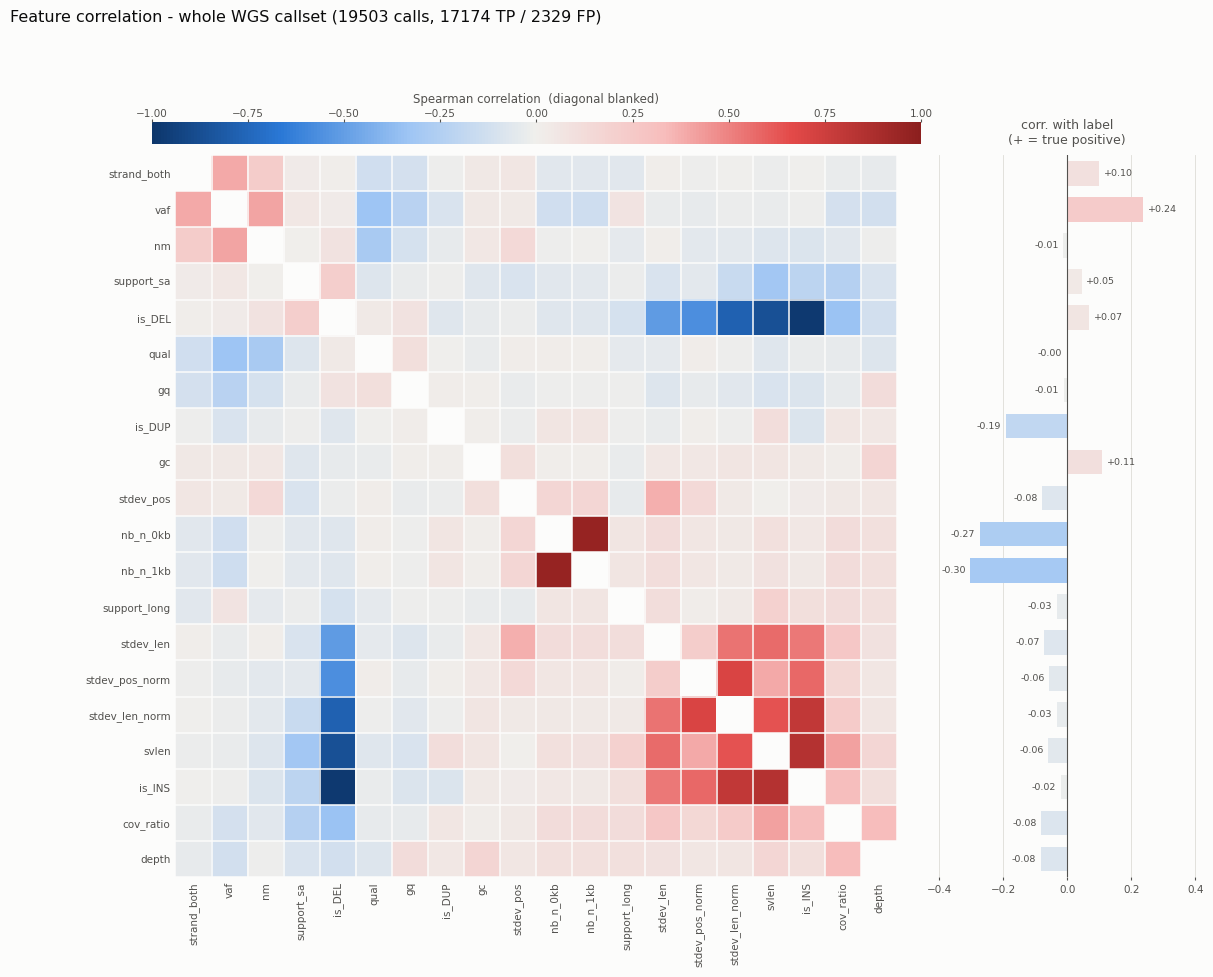


2 feature pairs with |r| >= 0.95 (one of each carries no extra information; the RF just splits its importance between them):


,feature_a,feature_b,r
0,is_DEL,is_INS,-0.982215
1,nb_n_0kb,nb_n_1kb,0.954695



per-feature association with the label (auc_alone 0.5 = no monotone signal; mutual_info catches non-monotone too):


,feature,spearman_y,auc_alone,mutual_info,auc_dist
0,gc,0.108,0.597,0.0373,0.097
1,nb_n_1kb,-0.303,0.333,0.0354,0.167
2,vaf,0.238,0.712,0.0323,0.212
3,nb_n_0kb,-0.273,0.355,0.0290,0.145
4,svlen,-0.059,0.448,0.0274,0.052
5,stdev_len,-0.072,0.438,0.0212,0.062
6,stdev_len_norm,-0.031,0.473,0.0199,0.027
7,qual,-0.002,0.499,0.0176,0.001
8,depth,-0.083,0.426,0.0137,0.074
9,nm,-0.012,0.489,0.0130,0.011


In [69]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.gridspec import GridSpec
from sklearn.feature_selection import mutual_info_classif

# diverging ramp: blue (negative) <- neutral gray -> red (positive),
# equal step count per arm, gray midpoint so "no correlation" reads as nothing.
CORR_CMAP = LinearSegmentedColormap.from_list(
    "corr", ["#0d366b", "#2a78d6", "#9ec5f4", "#f0efec", "#f7bdbc", "#e34948", "#8c1f1e"])
SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dedcd6"


def feature_correlations(X_raw, yy, method="spearman", cluster=True):
    """Feature-feature correlation matrix plus each feature's correlation with y.

    X_raw must be the UNFILLED matrix. Correlating on the -1 missing sentinel
    turns "no value" into a real number and manufactures structure that is not
    in the data -- every feature that is missing on the same rows would look
    correlated. Pass featurize(...) without .fillna(-1).

    Spearman by default: svlen, support, depth and the nb_ counts are heavily
    skewed, and Pearson on those mostly reports the outliers.
    """
    Z = X_raw.apply(pd.to_numeric, errors="coerce")
    dropped = [c for c in Z.columns if Z[c].nunique(dropna=True) <= 1]
    if dropped:
        print(f"constant in this callset, no correlation defined: {dropped}")
    Z = Z.drop(columns=dropped)

    C   = Z.corr(method=method)                                    # pairwise-complete
    lab = Z.corrwith(pd.Series(yy, index=Z.index), method=method)

    order = list(C.columns)
    if cluster and len(order) > 2:
        try:
            from scipy.cluster.hierarchy import leaves_list, linkage
            from scipy.spatial.distance import squareform
            d = 1 - C.fillna(0).to_numpy()
            np.fill_diagonal(d, 0.0)
            d = (d + d.T) / 2
            order = [C.columns[i] for i in
                     leaves_list(linkage(squareform(d, checks=False), "average"))]
        except Exception as e:                                     # scipy absent
            print(f"(no clustering, keeping column order: {e})")
    return C.loc[order, order], lab.reindex(order)


def plot_correlations(C, lab, title, annotate_max=16):
    n    = len(C)
    norm = Normalize(-1, 1)
    fig  = plt.figure(figsize=(min(0.40 * n + 5.5, 19), min(0.36 * n + 2.6, 16)),
                      facecolor=SURFACE)
    # colourbar on top: the rotated feature names live under the heatmap, so a
    # bottom colourbar collides with them
    gs   = GridSpec(2, 2, width_ratios=[1, 0.34], height_ratios=[0.030, 1],
                    wspace=0.03, hspace=0.030, figure=fig)
    axc, ax, axb = (fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0]),
                    fig.add_subplot(gs[1, 1]))

    # ---- feature x feature -------------------------------------------------
    M = C.to_numpy().copy()
    np.fill_diagonal(M, np.nan)          # a red diagonal stripe carries no information
    # rebuilt rather than .copy() -- Colormap.copy() only exists in matplotlib >= 3.4
    cmap = LinearSegmentedColormap.from_list("corr_bad", CORR_CMAP(np.linspace(0, 1, 256)))
    cmap.set_bad(SURFACE)
    im = ax.imshow(M, cmap=cmap, norm=norm, interpolation="nearest")
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(C.columns, rotation=90, fontsize=7.5, color=INK2)
    ax.set_yticklabels(C.index, fontsize=7.5, color=INK2)
    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which="minor", color=SURFACE, linewidth=1.1)   # 2px-ish surface gap between cells
    ax.tick_params(which="both", length=0)
    for s in ax.spines.values():
        s.set_visible(False)
    fig.suptitle(title, fontsize=11.5, color=INK, x=0.02, y=0.995,
                 ha="left", va="top")
    if n <= annotate_max:                                  # never a number in every cell
        for i in range(n):
            for j in range(n):
                v = C.iat[i, j]
                if np.isfinite(v) and abs(v) >= 0.3 and i != j:
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                            color="#ffffff" if abs(v) > 0.7 else INK)

    cb = fig.colorbar(im, cax=axc, orientation="horizontal")
    cb.set_label(f"{C.attrs.get('method', 'Spearman')} correlation  "
                 f"(diagonal blanked)", fontsize=8.5, color=INK2)
    cb.ax.xaxis.set_label_position("top"); cb.ax.xaxis.set_ticks_position("top")
    cb.ax.tick_params(labelsize=7.5, colors=INK2, length=2, pad=1)
    cb.outline.set_visible(False)

    # ---- correlation with the label ---------------------------------------
    v = lab.to_numpy(dtype=float)
    axb.barh(np.arange(n), v, color=CORR_CMAP(norm(np.nan_to_num(v))), height=0.68)
    axb.axvline(0, color=INK2, linewidth=0.8)
    axb.set_ylim(n - 0.5, -0.5)
    lim = max(0.12, float(np.nanmax(np.abs(v))) * 1.35)
    axb.set_xlim(-lim, lim)
    axb.set_yticks([]); axb.tick_params(labelsize=7.5, colors=INK2, length=2)
    axb.xaxis.grid(True, color=GRID, linewidth=0.6)
    axb.set_axisbelow(True)
    for s in axb.spines.values():
        s.set_visible(False)
    axb.set_title("corr. with label\n(+ = true positive)", fontsize=9, color=INK2, pad=8)
    for i, val in enumerate(v):                            # only ~n labels, so label them all
        if np.isfinite(val):
            axb.text(val + (0.012 * lim * 3 if val >= 0 else -0.012 * lim * 3), i,
                     f"{val:+.2f}", va="center", fontsize=6.8, color=INK2,
                     ha="left" if val >= 0 else "right")

    for a in (ax, axb, axc):
        a.set_facecolor(SURFACE)
    fig.patch.set_facecolor(SURFACE)
    plt.show()
    return fig


# ---- run it on the whole WGS callset ---------------------------------------

C, lab = feature_correlations(X, y, method="spearman")
C.attrs["method"] = "Spearman"
plot_correlations(C, lab,
                  f"Feature correlation - whole WGS callset "
                  f"({len(calls)} calls, {int((y==1).sum())} TP / {int((y==0).sum())} FP)")

# ---- near-duplicate features ------------------------------------------------
pairs = (C.where(np.triu(np.ones(C.shape), 1).astype(bool))
          .stack().rename("r").reset_index()
          .rename(columns={"level_0": "feature_a", "level_1": "feature_b"}))
red = pairs[pairs["r"].abs() >= 0.95].sort_values("r", key=np.abs, ascending=False)
print(f"\n{len(red)} feature pairs with |r| >= 0.95 (one of each carries no extra "
      f"information; the RF just splits its importance between them):")
display(red.reset_index(drop=True))

# ---- monotone correlation is not the only kind of signal --------------------
# Spearman sees only monotone relationships. cov_ratio is the obvious case where
# both too-high and too-low are suspicious, so its correlation can be ~0 while the
# feature is genuinely useful. AUC has the same blind spot; mutual information
# does not, so read the three together.
Xf   = X.reindex(columns=C.columns).fillna(-1)
mi   = mutual_info_classif(Xf, y, discrete_features=False, random_state=0)
auc  = [roc_auc_score(y, Xf[c]) for c in C.columns]
rank = (pd.DataFrame({"feature": C.columns,
                      "spearman_y": lab.reindex(C.columns).round(3).to_numpy(),
                      "auc_alone": np.round(auc, 3),
                      "mutual_info": np.round(mi, 4)})
          .assign(abs_spearman=lambda d: d.spearman_y.abs(),
                  auc_dist=lambda d: (d.auc_alone - 0.5).abs())
          .sort_values("mutual_info", ascending=False)
          .drop(columns="abs_spearman")
          .reset_index(drop=True))
print("\nper-feature association with the label "
      "(auc_alone 0.5 = no monotone signal; mutual_info catches non-monotone too):")
display(rank)

In [70]:
def counts_table(p, yy, grid=np.round(np.arange(0.05, 1.0, 0.05), 2)):
    """Counts are derived from the y you pass, so this works for OOF, chr22, anything."""
    n_sv, n_fp = int((yy == 1).sum()), int((yy == 0).sum())
    rows = []
    for t in grid:
        keep    = p >= t
        sv_kept = int((keep & (yy == 1)).sum());  sv_lost = n_sv - sv_kept
        fp_kept = int((keep & (yy == 0)).sum());  fp_rm   = n_fp - fp_kept
        n_out   = sv_kept + fp_kept
        rows.append({"thresh": t,
                     "SVs_kept": sv_kept, "SVs_lost": sv_lost,
                     "FPs_removed": fp_rm, "FPs_left": fp_kept,
                     "callset_n": n_out,
                     "FP_rate_%": round(100 * fp_kept / n_out, 1) if n_out else np.nan,
                     "FPs_per_SV_lost": round(fp_rm / sv_lost, 1) if sv_lost else np.inf})
    return pd.DataFrame(rows)

print(f"Baseline (no filter): {int((y_tr==1).sum())} real SVs + {int((y_tr==0).sum())} FPs "
      f"= {len(y_tr)} calls, FP rate {100*(y_tr==0).mean():.1f}%")
counts_table(oof, y_tr)

Baseline (no filter): 15955 real SVs + 2156 FPs = 18111 calls, FP rate 11.9%


,thresh,SVs_kept,SVs_lost,FPs_removed,FPs_left,callset_n,FP_rate_%,FPs_per_SV_lost
0,0.05,15954,1,28,2128,18082,11.8,28.0
1,0.10,15953,2,64,2092,18045,11.6,32.0
2,0.15,15949,6,127,2029,17978,11.3,21.2
3,0.20,15945,10,215,1941,17886,10.9,21.5
4,0.25,15928,27,310,1846,17774,10.4,11.5
5,0.30,15894,61,411,1745,17639,9.9,6.7
6,0.35,15825,130,536,1620,17445,9.3,4.1
7,0.40,15750,205,674,1482,17232,8.6,3.3
8,0.45,15641,314,784,1372,17013,8.1,2.5
9,0.50,15500,455,913,1243,16743,7.4,2.0


**Threshold.** Picked on the training-chromosome OOF predictions only. chr22 stays sealed
until it is locked -- tuning against chr22 would turn it back into a training set.

`FPs_per_SV_lost` above is the number that matters: it is the exchange rate you are buying.
The 99%-retention target below is set by a handful of calls, so the jackknife and bootstrap
tell you whether the exact value is meaningful or noise.

In [74]:
TARGET_TP_KEPT = 0.99                                   # how many TP to keep
GRID = np.round(np.arange(0.02, 1.0, 0.005), 3)

def pick_thresh(p, yy, target=TARGET_TP_KEPT):
    """Highest threshold that still retains `target` of the true positives."""
    ok = GRID[[bool((p[yy == 1] >= t).mean() >= target) for t in GRID]]
    return float(ok.max()) if len(ok) else 0.0

THRESH = pick_thresh(oof, y_tr)
print(f"THRESH = {THRESH}   "
      f"(keeps {(oof[y_tr==1] >= THRESH).mean():.3%} of TP, "
      f"removes {(oof[y_tr==0] < THRESH).mean():.1%} of FP)")

# --- is that number stable? -------------------------------------------------
jack = np.array([pick_thresh(oof[g_tr != c], y_tr[g_tr != c]) for c in sorted(set(g_tr))])
print(f"drop-one-chromosome : {jack.min():.3f} - {jack.max():.3f}  (median {np.median(jack):.3f})")

rng, boot = np.random.default_rng(0), []
for _ in range(200):
    i = rng.integers(0, len(y_tr), len(y_tr))
    boot.append(pick_thresh(oof[i], y_tr[i]))
boot = np.array(boot)
print(f"bootstrap 5-95%     : {np.percentile(boot, 5):.3f} - {np.percentile(boot, 95):.3f}")
if np.percentile(boot, 95) - np.percentile(boot, 5) > 0.15:
    print("\n!! wide band -- 'the threshold that keeps exactly 99%' is not well determined.\n"
          "   Prefer choosing an operating point from the FPs_per_SV_lost column instead.")

tab = pd.DataFrame([{"thresh": t,
                     "tp_kept":    (oof[y_tr == 1] >= t).mean(),
                     "fp_removed": (oof[y_tr == 0] <  t).mean(),
                     "n_tp_lost":  int((oof[y_tr == 1] <  t).sum()),
                     "n_fp_left":  int((oof[y_tr == 0] >= t).sum())}
                    for t in np.round(np.arange(0.05, 1.0, 0.025), 3)])
tab

THRESH = 0.37   (keeps 99.041% of TP, removes 27.3% of FP)
drop-one-chromosome : 0.370 - 0.375  (median 0.375)
bootstrap 5-95%     : 0.355 - 0.385


,thresh,tp_kept,fp_removed,n_tp_lost,n_fp_left
0,0.050,0.999937,0.012987,1,2128
1,0.075,0.999937,0.019944,1,2113
2,0.100,0.999875,0.029685,2,2092
3,0.125,0.999812,0.043135,3,2063
4,0.150,0.999624,0.058905,6,2029
5,0.175,0.999561,0.078850,7,1986
6,0.200,0.999373,0.099722,10,1941
7,0.225,0.998997,0.120594,16,1896
8,0.250,0.998308,0.143785,27,1846
9,0.275,0.997242,0.163265,44,1804


In [75]:
#Looking at the cell above, you start removing a significant amount of FP around 0.25 in my opinion, could be worth changing


In [77]:
# ---- the one-shot held-out test. Do not go back and change THRESH after this. --
rf.fit(X_tr, y_tr)
p_te = rf.predict_proba(X_te)[:, 1]

print(f"{test_label} AUC {roc_auc_score(y_te, p_te):.3f}   "
      f"AP {average_precision_score(y_te, p_te):.3f}      "
      f"(train-chrom OOF: AUC {roc_auc_score(y_tr, oof):.3f})")

k = p_te >= THRESH
print(f"\n@ locked THRESH={THRESH}")
print(f"   TP kept     {int((k  & (y_te == 1)).sum()):4d}/{int((y_te == 1).sum())}")
print(f"   FP removed  {int((~k & (y_te == 0)).sum()):4d}/{int((y_te == 0).sum())}")
print(f"\n   OOF said to expect: TP kept {(oof[y_tr==1] >= THRESH).mean():.1%}, "
      f"FP removed {(oof[y_tr==0] < THRESH).mean():.1%}")

print()
display(counts_table(p_te, y_te))

pd.Series(rf.feature_importances_, index=FEATS).sort_values(ascending=False)

['chr22', 'chr12'] AUC 0.913   AP 0.984      (train-chrom OOF: AUC 0.892)

@ locked THRESH=0.37
   TP kept     1209/1219
   FP removed    55/173

   OOF said to expect: TP kept 99.0%, FP removed 27.3%



,thresh,SVs_kept,SVs_lost,FPs_removed,FPs_left,callset_n,FP_rate_%,FPs_per_SV_lost
0,0.05,1219,0,1,172,1391,12.4,inf
1,0.10,1219,0,8,165,1384,11.9,inf
2,0.15,1219,0,13,160,1379,11.6,inf
3,0.20,1219,0,20,153,1372,11.2,inf
4,0.25,1219,0,29,144,1363,10.6,inf
5,0.30,1218,1,37,136,1354,10.0,37.0
6,0.35,1211,8,50,123,1334,9.2,6.2
7,0.40,1205,14,62,111,1316,8.4,4.4
8,0.45,1197,22,74,99,1296,7.6,3.4
9,0.50,1186,33,86,87,1273,6.8,2.6


vaf               0.173816
gc                0.122571
svlen             0.094941
nb_n_1kb          0.080191
nm                0.077560
stdev_len_norm    0.073612
depth             0.068432
cov_ratio         0.063360
stdev_len         0.056840
nb_n_0kb          0.042478
stdev_pos         0.041264
stdev_pos_norm    0.038549
qual              0.024643
gq                0.013134
strand_both       0.008444
is_DUP            0.006729
is_DEL            0.005125
is_INS            0.005029
support_long      0.001685
support_sa        0.001596
dtype: float64

Apply the filter

In [78]:
def apply_filter(in_vcf, out_vcf, model=None, thresh=None, feats=None, prob_by_id=None):
    """Annotate a VCF with RF_PROB and PASS / RF_FAIL.

    prob_by_id : honest (out-of-fold or held-out) probability per VCF ID. Use this for
                 any record the model was trained on -- scoring those with the fitted
                 model gives memorised probabilities near 0/1 and meaningless counts.
    model      : used only for records absent from prob_by_id (i.e. genuinely unseen).
    """
    thresh = THRESH if thresh is None else thresh
    feats  = FEATS  if feats  is None else feats
    summary = variant_summary if "variant_summary" in globals() else None
    df = attach_variant_summary(read_vcf(in_vcf), summary)

    p_model = None
    if model is not None:
        p_model = model.predict_proba(
            featurize(df).reindex(columns=feats).fillna(-1))[:, 1]

    if prob_by_id is not None:
        p = np.array([prob_by_id.get(i, np.nan) for i in df["ID"]], dtype=float)
        miss = np.isnan(p)
        if miss.any():
            if p_model is None:
                raise ValueError(f"{miss.sum()} records missing from prob_by_id and no model given")
            p[miss] = p_model[miss]
            print(f"  note: {int(miss.sum())} records not in prob_by_id, scored with the model")
    else:
        if p_model is None:
            raise ValueError("pass model= or prob_by_id=")
        p = p_model

    op = gzip.open if str(in_vcf).endswith(".gz") else open
    i = 0
    with op(in_vcf, "rt") as fh, open(out_vcf, "w") as out:
        for line in fh:
            if line.startswith("#"):
                if line.startswith("#CHROM"):
                    out.write('##FILTER=<ID=RF_FAIL,Description="Random forest SV FP filter">\n')
                    out.write('##INFO=<ID=RF_PROB,Number=1,Type=Float,Description="RF probability the call is a true positive">\n')
                out.write(line)
                continue
            f = line.rstrip("\n").split("\t")
            f[6] = "PASS" if p[i] >= thresh else "RF_FAIL"
            f[7] = f[7] + ";RF_PROB=%.4f" % p[i]
            out.write("\t".join(f) + "\n")
            i += 1
    print(f"{out_vcf}: {i} records, {int((p < thresh).sum())} flagged RF_FAIL")
    return p


# honest probability for every call: OOF on the training chromosomes,
# held-out model prediction on chr22
prob_by_id = dict(zip(calls.iloc[tr_idx]["ID"], oof))
prob_by_id.update(zip(calls.iloc[te_idx]["ID"], p_te))
assert len(prob_by_id) == len(calls), "duplicate IDs between tp-comp.vcf and fp.vcf"

OUT = "/opt/notebooks"
p_tp = apply_filter(TP_VCF_WGS, f"{OUT}/filtered_tp.vcf", model=rf, prob_by_id=prob_by_id)
p_fp = apply_filter(FP_VCF_WGS, f"{OUT}/filtered_fp.vcf", model=rf, prob_by_id=prob_by_id)

/opt/notebooks/filtered_tp.vcf: 17174 records, 163 flagged RF_FAIL
/opt/notebooks/filtered_fp.vcf: 2329 records, 644 flagged RF_FAIL


In [79]:
OUT = "/opt/notebooks"
p_tp = apply_filter(TP_VCF_22, f"{OUT}/filtered_tp_22.vcf", model=rf)
p_fp = apply_filter(FP_VCF_22, f"{OUT}/filtered_fp_22.vcf", model=rf)

/opt/notebooks/filtered_tp_22.vcf: 483 records, 15 flagged RF_FAIL
/opt/notebooks/filtered_fp_22.vcf: 147 records, 50 flagged RF_FAIL


In [80]:
# ---- consistency check -----------------------------------------------------
# These should now line up with the OOF table. If filtered_fp.vcf flags far more
# than the OOF "fp_removed" column predicts, something is being scored in-sample.
exp_tp_lost = (oof[y_tr == 1] < THRESH).sum() + int(((p_te < THRESH) & (y_te == 1)).sum())
exp_fp_rm   = (oof[y_tr == 0] < THRESH).sum() + int(((p_te < THRESH) & (y_te == 0)).sum())
print(f"expected  TP flagged {exp_tp_lost}/{int((y==1).sum())}   "
      f"FP flagged {exp_fp_rm}/{int((y==0).sum())}")
print(f"observed  TP flagged {int((p_tp < THRESH).sum())}   "
      f"FP flagged {int((p_fp < THRESH).sum())}")
print("\n(small differences are records on contigs dropped by KEEP_CHROM)")

expected  TP flagged 163/17174   FP flagged 644/2329
observed  TP flagged 15   FP flagged 50

(small differences are records on contigs dropped by KEEP_CHROM)


In [43]:
# def subset_chrom(in_vcf, out_vcf, chrom=None):
#     chrom = TEST_CHROM if chrom is None else chrom
#     op = gzip.open if str(in_vcf).endswith(".gz") else open
#     n = 0
#     with op(in_vcf, "rt") as fh, open(out_vcf, "w") as out:
#         for line in fh:
#             if line.startswith("#"):
#                 out.write(line); continue
#             if line.split("\t")[0] == chrom:
#                 out.write(line); n += 1
#     print(f"{out_vcf}: {n} records")

# subset_chrom(TP_VCF_WGS, f"tp-comp.{TEST_CHROM}.vcf", chrom=22)
# subset_chrom(FP_VCF_WGS, f"fp.{TEST_CHROM}.vcf",chrom=22)

# # chr22 was never trained on, so the fitted model is honest here
# # apply_filter(f"tp-comp.{TEST_CHROM}.vcf", f"filtered_tp_{TEST_CHROM}.vcf", model=rf)
# # apply_filter(f"fp.{TEST_CHROM}.vcf",      f"filtered_fp_{TEST_CHROM}.vcf", model=rf)

tp-comp.['chr22', 'chr12'].vcf: 0 records
fp.['chr22', 'chr12'].vcf: 0 records


In [81]:
# ---- production model ------------------------------------------------------
# Only once you are happy with the chr22 result. Trains on every chromosome
# including chr22; THRESH carries over from the OOF selection (slightly
# conservative, since more data makes the probabilities marginally sharper).
# Never evaluate this model on tp-comp.vcf / fp.vcf -- it has seen all of them.
import joblib

rf_final = clone(rf).fit(X, y)
joblib.dump({"model": rf_final, "feats": FEATS, "thresh": THRESH,
             "trained_on": sorted(set(calls["CHROM"]), key=chrkey),
             "test_label": test_label,
             "oof_auc": float(roc_auc_score(y_tr, oof)),
             "heldout_auc": float(roc_auc_score(y_te, p_te))},
            f"{OUT}/sv_rf_filter_final.joblib")
print("saved")

saved
